## 3. Stats Review

### Motivation: Why do we need Standard Errors of Estimates?

- When estimating sample parameters from data, we typically want to measure the **standard error** $$SE = \frac{\sigma}{\sqrt{n}}$$

- This is usually handwaved as "uncertainty" in the estimate. This "uncertainty" is not in the estimation of the sample parameter (which follows a fixed formula), but in how well the sample parameter reflects the true population parameter!!

- The motivation for this may create some confusion, so let's motivate it in the code block below

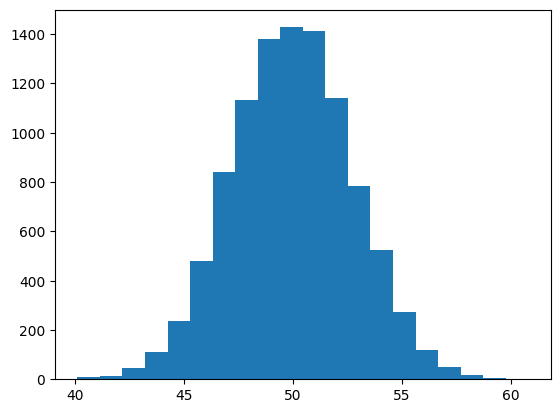

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

'''
Let's suppose we have a school with 50 students. At some given point in time, the student's average ability to perform in an exam is about 50/100, with a standard deviation of 15. 
'''
student_count = 30
true_population_mean = 50
true_population_stddev = 15

def run_exam():
    exam_results = np.random.normal(loc=true_population_mean, scale=true_population_stddev, size=student_count)
    return exam_results

'''
Let's suppose we have godlike powers, and we are able to run the exam across 10_000 parallel universes with the same students, on the same day, with the same condition. For each universe, we compute the average exam score
'''
simulated_universes = 10_000
average_scores_across_universes = [np.mean(run_exam()) for _ in range(simulated_universes)]

'''
Even though our students' "true" ability is 50/100, we end up with some scattering of average scores around the 50! Some exams even average 40 points, a full 10 points below 50.
'''
plt.hist(average_scores_across_universes, bins=20);

- The above code block shows that, every time an experiment is run, the parameter you estimate using the experimental data may not be exactly at the true population mean
    - Yes it is "more likely" that you are close to the mean, but it is also possible that your estimate can be quite off!

- How can I improve my estimation?
    - One strategy is simple: Use more data!!

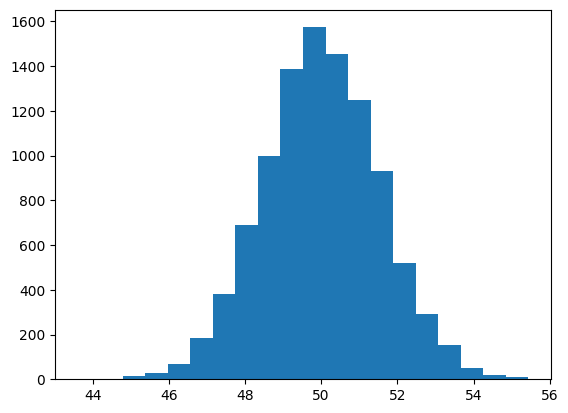

In [3]:
'''
When we give the exam to more students, even though the underlying ability of the students do not change, we get better estimates on average! The more extreme score is ~55, instead of 60
'''
student_count = 100
average_scores_across_universes = [np.mean(run_exam()) for _ in range(simulated_universes)]
plt.hist(average_scores_across_universes, bins=20);

- It is intuitive that, if our underlying data is more dispersed, we should be more uncertain about the estimate we get from an experiment. But now we also know that the certainty of the estimate further depends on our sample count as well! The more data we have, the less uncertain we are

- This is exactly what the standard error formula $SE = \frac{\sigma}{\sqrt{n}}$ tells us!

#### Practical Pitfalls in not accounting for standard errors

- The theoretical introduction is great. But practically, how does this matter? As it turns out, not accounting for standard errors can lead us to draw some famously terrible conclusions

- Let's take aim at one popular spurious conclusion that was famously pushed in the 90s: "Smaller class size leads to better student outcomes"

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns

In [5]:
data = pd.read_csv('./data/3_enem_scores.csv')

In [6]:
'''
A popular line of thought in the 90s was to compare top performing schools with non-top schools, and attribute difference in performance to any differences in the dataset. Let's try that logic out here. We'll assign the top 10% of schools into 1 group, and the other 90% into another, and compare the differences in number_of_students
'''
data_clean = (
    data
    .assign(
        school_type = lambda df: np.select(
            [df['avg_score'] >= np.quantile(df['avg_score'], 0.985)],
            ['Top'],
            default='Not Top'
        )
    )
    .groupby('school_type', as_index=False)
    .agg({'number_of_students': 'mean'})
    
)
data_clean

,school_type,number_of_students
0,Not Top,139.865614
1,Top,117.168126


- Lo and behold, top schools have fewer students on average than bottom schools. Therefore, the logic went, having fewer students on average must be good for average scores!!

- But wait, what happens when we look at bottom schools as well?

<Axes: xlabel='number_of_students', ylabel='avg_score'>

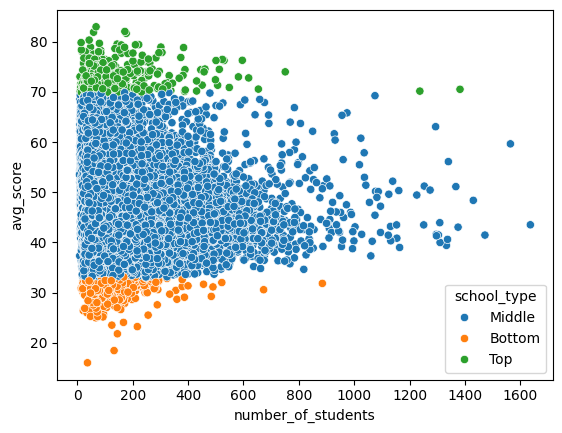

In [7]:
'''
As it turns out, bottom schools ALSO have fewer students on average compared to the other schools. WTF?
'''
data_clean = (
    data
    .assign(
        school_type = lambda df: np.select(
            [df['avg_score'] >= np.quantile(df['avg_score'], 0.985), df['avg_score'] <= np.quantile(df['avg_score'], 0.015)],
            ['Top', 'Bottom'],
            default='Middle'
        )
    )
)
(
    data_clean
    .groupby('school_type', as_index=False)
    .agg({'number_of_students': 'mean'})
)

'''
In fact, both the top and bottom schools have lower average student counts.
'''
sns.scatterplot(x='number_of_students', y='avg_score', data=data_clean, hue='school_type')

- As it turns out, smaller student counts drive the extremity of scores averages on both the top and bottom ends of the distribution!

- If only there was a way to adjust for the uncertainty created by small samples :)

### Standard Errors of Estimates

- Now that we've properly motivated why standard errors are important, let's figure out how they are related with the **Average Treatment Effect** discussion we had in chapters 1 and 2

In [8]:
import pandas as pd
import numpy as np

data = pd.read_csv('./data/2_online_classroom.csv')
data.head()

,gender,asian,black,hawaiian,hispanic,unknown,white,format_ol,format_blended,falsexam
0,0,0.0,0.0,0.0,0.0,0.0,1.0,0,0.0,63.29997
1,1,0.0,0.0,0.0,0.0,0.0,1.0,0,0.0,79.96000
2,1,0.0,0.0,0.0,0.0,0.0,1.0,0,1.0,83.37000
3,1,0.0,0.0,0.0,0.0,0.0,1.0,0,1.0,90.01994
4,1,0.0,0.0,0.0,0.0,0.0,1.0,1,0.0,83.30000


In [ ]:
'''
Recall: we found that the ATE is simply the difference betweeen the average exam results for each of the teaching formats!
'''
avg_results = (
    data
    .assign(
        teaching_format = lambda df: np.select(
            [df['format_ol']==1, df['format_blended']==1],
            ['Online', 'Blended'],
            default='In-Person'
        )
    )
    .groupby('teaching_format', as_index=False)
    .agg({'falsexam':['mean', 'std', 'count']})
)
avg_results.columns = ['teaching_format', 'avg_results', 'std_results', 'count_group']

'''
Using these results, we can calculate the standard error of the mean for each of the teaching formats.
'''
(
    avg_results
    .assign(
        standard_error = lambda df: df['std_results']/np.sqrt(df['count_group'])
    )
)

,teaching_format,avg_results,std_results,count_group,standard_error
0,Blended,77.093731,10.085906,109,0.966055
1,In-Person,78.547485,9.556128,120,0.872351
2,Online,73.635263,14.903313,94,1.537159


### Confidence Intervals

- We know that the averages are different for each of the teaching formats. But are they sufficiently different?
    - Intuitively, 73.63 is more different from 78.54 compared to 77.09
    - But how different is it REALLY?
    - Recall from the section above that sample size affects the extremity of results observed. So is 94 observations for `Online` classes sufficient to conclude that it produces different scores from the other teaching formats?

- This is where the `standard_error` comes into the picture!

- How does this work? We'll use `Online` as an example
    - Let us assume that the `avg_result` computed for the `Online` classes $\hat{\mu} = 73.64$ is a true reflection of the true population mean $\mu$ for online classes
    - Let us assume that the `std_results` computed for the `Online` classes $\hat{\sigma} = 14.90$ is a true reflection of the true population mean $\sigma$ for online classes
    - Based on the standard error formula $SE = \frac{\hat{\sigma}}{\sqrt{n}}$, with a sample size 94, we assert that the sample mean $\hat{\mu}$ follows the distribution $\hat{\mu} \sim N(73.64, 1.54)$ 

- If the assumption that $\hat{\mu} \sim N(73.64, 1.54)$ is true, it follows that the 95% confidence interval of $\hat{\mu}$ must be $(\hat{\mu} - 1.96 * SE, \hat{\mu} + 1.96 * SE)$ 
    - 95% CI means you have 2.5% of the observations at each of the tails
    - For a standard normal distribution, we know that the critical values for 0.975 and 0.025 are at 1.96 and -1.96 respectively (look up a std normal table if you don't)


In [62]:
'''
Computing confidence intervals for each group
'''

import scipy

conf_ints = (
    avg_results
    .assign(
        standard_error = lambda df: df['std_results']/np.sqrt(df['count_group'])
    )
)

pct_99_critical_val = ('99%', scipy.stats.norm.ppf(0.995))
pct_95_critical_val = ('95%', scipy.stats.norm.ppf(0.975))
pct_90_critical_val = ("90%", scipy.stats.norm.ppf(0.95))

for pval, critical_value in [pct_90_critical_val,pct_95_critical_val,pct_99_critical_val]:
    print(f"{pval} CI:")
    print(f'\t{critical_value=}')
    for format,avg,se,counts,ci_lb,ci_ub in zip(conf_ints['teaching_format'], conf_ints['avg_results'], conf_ints['std_results'], conf_ints['count_group'], conf_ints['avg_results'] - (critical_value * conf_ints['standard_error']), conf_ints['avg_results'] + (critical_value * conf_ints['standard_error'])):
        print(f'\t{format}: {avg=}, {se=}, {counts=}, ci=({ci_lb}, {ci_ub})')

90% CI:
	critical_value=np.float64(1.644853626951472)
	Blended: avg=77.09373137614679, se=10.085905791502876, counts=109, ci=(75.50471301657225, 78.68274973572133)
	In-Person: avg=78.54748458333333, se=9.556128010561435, counts=120, ci=(77.1125946374654, 79.98237452920125)
	Online: avg=73.63526308510637, se=14.903313295899233, counts=94, ci=(71.10686087524809, 76.16366529496466)
95% CI:
	critical_value=np.float64(1.959963984540054)
	Blended: avg=77.09373137614679, se=10.085905791502876, counts=109, ci=(75.2002992162827, 78.98716353601088)
	In-Person: avg=78.54748458333333, se=9.556128010561435, counts=120, ci=(76.83770775602252, 80.25726141064413)
	Online: avg=73.63526308510637, se=14.903313295899233, counts=94, ci=(70.62248602789292, 76.64804014231983)
99% CI:
	critical_value=np.float64(2.5758293035489004)
	Blended: avg=77.09373137614679, se=10.085905791502876, counts=109, ci=(74.60533971174367, 79.58212304054992)
	In-Person: avg=78.54748458333333, se=9.556128010561435, counts=120, ci

#### Interpreting a confidence interval

- A 95% confidence interval simply means, if I do the experiment 100 times, the true mean should fall within 95% of the confidence intervals computed using this methodology
    - So the "95% confidence" refers to the confidence in the process generating the confidence interval (i.e. if I run this process 100 times, I'll get the true mean within this interval 95% of the time)
    - It is NOT the confidence for this particular confidence interval (i.e. NOT "this interval has 95% chance of being correct")

- Let's show this via simulation

In [52]:
true_population_mean = 75
true_population_std = 25
obs = 100

def do_one_experiment():
    sample = np.random.normal(true_population_mean, true_population_std, obs)
    mean = np.mean(sample)
    stddev = np.std(sample, ddof=1)
    stderr = stddev / obs**0.5
    pct_95_critical_value = scipy.stats.norm.ppf(0.975)
    pct_95_conf_int_lb = mean - (pct_95_critical_value * stderr)
    pct_95_conf_int_ub = mean + (pct_95_critical_value * stderr)
    return bool(pct_95_conf_int_lb <= true_population_mean <= pct_95_conf_int_ub)

np.mean([do_one_experiment() for _  in range(10_000)])

np.float64(0.9464)

### Hypothesis Testing

- Ok, so we know the confidence intervals. And we know the means. But we still have not answered the main question: **"Does online learning lead to worse outcomes than In-Person learning?"**

```text
90% CI:
	critical_value=np.float64(1.644853626951472)
	Blended: avg=77.09373137614679, se=10.085905791502876, counts=109, ci=(75.50471301657225, 78.68274973572133)
	In-Person: avg=78.54748458333333, se=9.556128010561435, counts=120, ci=(77.1125946374654, 79.98237452920125)
	Online: avg=73.63526308510637, se=14.903313295899233, counts=94, ci=(71.10686087524809, 76.16366529496466)
95% CI:
	critical_value=np.float64(1.959963984540054)
	Blended: avg=77.09373137614679, se=10.085905791502876, counts=109, ci=(75.2002992162827, 78.98716353601088)
	In-Person: avg=78.54748458333333, se=9.556128010561435, counts=120, ci=(76.83770775602252, 80.25726141064413)
	Online: avg=73.63526308510637, se=14.903313295899233, counts=94, ci=(70.62248602789292, 76.64804014231983)
99% CI:
	critical_value=np.float64(2.5758293035489004)
	Blended: avg=77.09373137614679, se=10.085905791502876, counts=109, ci=(74.60533971174367, 79.58212304054992)
	In-Person: avg=78.54748458333333, se=9.556128010561435, counts=120, ci=(76.3004569394302, 80.79451222723645)
	Online: avg=73.63526308510637, se=14.903313295899233, counts=94, ci=(69.67580286530475, 77.594723304908)
```

- Let's now apply what we computed earlier to draw some conclusion about this question

- To apply hypothesis testing, we make the following assumptions
    - The true population average score for `Online` teaching format follows the distribution $\mu_{\text{Online}} \sim N(73.64, \frac{14.90}{\sqrt{94}})$
    - The true population average score for `In-person` teaching format follows the distribution $\mu_{\text{In-person}} \sim N(78.55, \frac{9.56}{\sqrt{120}})$

- We want to know if the parameter $D$ where $D = \mu_{\text{In-person}} - \mu_{\text{Online}}$ is significant
    - Both $\mu_{\text{In-person}}$ and $\mu_{\text{Online}}$ are normally distributed
    - Due to random assignment, both the means are independent of each other

- Therefore, $D \sim N(\mu_{\text{In-person}} - \mu_{\text{Online}}, \sqrt{\frac{(14.9)^2}{94} + \frac{(9.56)^2}{120}})$
    - This is just adding 2 independent normal distributions together! Nothing special

In [81]:
import pandas as pd
import numpy as np
conf_ints.head()

,teaching_format,avg_results,std_results,count_group,standard_error
0,Blended,77.093731,10.085906,109,0.966055
1,In-Person,78.547485,9.556128,120,0.872351
2,Online,73.635263,14.903313,94,1.537159


In [91]:
mean_of_diff = list(conf_ints.loc[conf_ints['teaching_format'] == 'In-Person', 'avg_results'])[0] - list(conf_ints.loc[conf_ints['teaching_format'] == 'Online', 'avg_results'])[0]
standard_error_of_diff = (list(conf_ints.loc[conf_ints['teaching_format'] == 'In-Person', 'standard_error'])[0]**2 + list(conf_ints.loc[conf_ints['teaching_format'] == 'Online', 'standard_error'])[0]**2)**0.5

pct_95_critical_value = scipy.stats.norm.ppf(0.975)

def test_diff_significantly_different_from(null_hypothesis_value=0):
    return bool(
        abs((mean_of_diff - null_hypothesis_value) / standard_error_of_diff) >= pct_95_critical_value
    )

test_diff_significantly_different_from(null_hypothesis_value=0)

True

#### Hypothesis Test vs Confidence Interval

- There are commonly 2 ways to "test" for statistical significance:
    - The first, is to check whether the confidence intervals of $\mu_{\text{In-person}}$ and $\mu_{\text{Online}}$ overlap
    - The second, is to do a proper hypothesis test

- Is there a difference between these methods? Let's see!!

In [93]:
import pandas as pd
import numpy as np
import scipy

In [ ]:
def confidence_intervals_intersect(ci_A_lb,ci_A_ub,ci_B_lb,ci_B_ub):
    return not ((ci_A_lb > ci_B_ub) or (ci_A_ub < ci_B_lb))

def diff_confidence_interval_contains_0(ci_D_lb,ci_D_ub):
    return not ((ci_D_lb > 0) or (ci_D_ub < 0)) ##if lower bound is higher than 0 or upper bound lower than 0, then it does not contain 0

def hypothesis_test(diff_mean, diff_std):
    return bool(abs((diff_mean - 0) / diff_std) <= pct_95_critical_value)

In [223]:
true_mean_A = 50
true_std_A = 10
obs_A = 200

true_mean_B = 50
true_std_B = 10
obs_B = 200

ci_intersect = []
diff_ci_intersect_0 = []
proper_hypothesis_test = []

def do_one_simulation():
    data_A = np.random.normal(true_mean_A, true_std_A, obs_A)
    data_B = np.random.normal(true_mean_B, true_std_B, obs_B)
    sample_mean_A, sample_std_A = np.mean(data_A), np.std(data_A, ddof=1)
    sample_mean_B, sample_std_B = np.mean(data_B), np.std(data_B, ddof=1)
    stderr_A = sample_std_A / obs_A**0.5
    stderr_B = sample_std_B / obs_B**0.5

    pct_95_critical_value = scipy.stats.norm.ppf(0.975)
    ci_A_lb,ci_A_ub = sample_mean_A - (pct_95_critical_value * stderr_A), sample_mean_A + (pct_95_critical_value * stderr_A)
    ci_B_lb,ci_B_ub = sample_mean_B - (pct_95_critical_value * stderr_B), sample_mean_B + (pct_95_critical_value * stderr_B)

    diff_mean = sample_mean_A - sample_mean_B
    diff_std = (stderr_A**2 + stderr_B**2)**0.5
    ci_D_lb, ci_D_ub = diff_mean - (pct_95_critical_value * diff_std), diff_mean + (pct_95_critical_value * diff_std)

    ci_intersect.append(confidence_intervals_intersect(ci_A_lb,ci_A_ub,ci_B_lb,ci_B_ub))
    diff_ci_intersect_0.append(diff_confidence_interval_contains_0(ci_D_lb, ci_D_ub))
    proper_hypothesis_test.append(hypothesis_test(diff_mean, diff_std))

[do_one_simulation() for _ in range(10_000)];
np.mean(ci_intersect), np.mean(diff_ci_intersect_0), np.mean(proper_hypothesis_test)

(np.float64(0.9939), np.float64(0.9503), np.float64(0.9503))

- Notice how checking the interesection of confidence interval gives us an overly strict check for significance!! In this case, the intervals overlap 99.4% of the time, although each interval was computed at 95% confidence

- Taking a diff and doing a hypothesis test (or, equivalently, checking if the metric `D` crosses 0) will give us the desired statistical confidence

### P-Value

- So far, we've talked about using the 95% confidence interval, and we reject the test statistic if its absolute value exceeds 1.96 critical value

- This test statistic $\frac{x - \mu}{\sigma}$ is also known as the **p-value** of the hypothesis test

- What does this p-value tell us?
    - It is **NOT** the probability that the null hypothesis is true given the data $P(H_0 | \text{Data})$. This is a severe misconception.
    - Rather, it is the probability of seeing the data given the null hypothesis is true $P(\text{Data} | H_0)$

- i.e. If we see a p-value of 0.002, that means that the probability of seeing a z-statistic this extreme under the null hypothesis $H_0$ is 0.2%